In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [91]:
# create the dataffram
df=pd.read_csv("train_transaction.csv")

In [92]:
ident = pd.read_csv('train_identity.csv')
df = df.merge(ident, on='TransactionID', how='left')
print(df.shape)
print('DeviceType' in df.columns)

(583557, 434)
True


In [93]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583552,3570552,0,15608673,117.00,W,6951,111.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
583553,3570553,0,15608700,67.95,W,8528,215.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
583554,3570554,0,15608734,59.00,W,2616,327.0,150.0,discover,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
583555,3570555,0,15608744,35.95,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
df.describe(

)

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.835570e+05,583557.000000,5.835570e+05,583557.000000,583557.000000,574709.000000,581992.000000,579311.000000,518413.000000,518413.000000,...,138179.000000,44686.000000,138128.000000,138076.000000,5101.000000,5111.000000,4696.000000,5074.000000,5105.000000,76922.000000
mean,3.278778e+06,0.034900,7.272538e+06,134.668322,9897.207020,362.561698,153.207793,199.292430,290.737381,86.798942,...,189.447470,14.235353,353.115321,403.792875,368.364046,16.006261,12.789395,329.472408,148.981195,26.515379
std,1.684585e+05,0.183526,4.553236e+06,238.069132,4901.138308,157.821861,11.355881,41.227984,101.747037,2.696891,...,30.373912,1.557677,141.145797,152.081005,198.729249,6.903951,2.352472,97.493379,32.169078,3.740424
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.132889e+06,0.000000,3.005396e+06,43.146000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.278778e+06,0.000000,7.182271e+06,68.500000,9665.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,147.000000,24.000000
75%,3.424667e+06,0.000000,1.106228e+07,125.000000,14182.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,488.000000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.570556e+06,1.000000,1.560879e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


which feature to select that is the typical 8 & then from the remaining c, d & m which to choose
so for that lets check the no of nulls in each col so that we can select which one to 

In [95]:
c_cols = ['C1','C2','C3','C4','C5',
          'C6','C7','C8','C9','C10',
          'C11','C12','C13','C14']

d_cols = ['D1','D2','D3','D4','D5',
          'D6','D7','D8','D9','D10',
          'D11','D12','D13','D14','D15']

m_cols = ['M1','M2','M3','M4','M5',
          'M6','M7','M8','M9']

groups = {'c_columns': c_cols, 'd_columns': d_cols, 'm_columns': m_cols}

trans=pd.read_csv('train_transaction.csv',usecols=c_cols+d_cols+m_cols)
for group_name, cols in groups.items():
    print(f"\n {group_name} null % ")
    print((trans[cols].isnull().sum() / len(trans) * 100).round(1))





 c_columns null % 
C1     0.0
C2     0.0
C3     0.0
C4     0.0
C5     0.0
C6     0.0
C7     0.0
C8     0.0
C9     0.0
C10    0.0
C11    0.0
C12    0.0
C13    0.0
C14    0.0
dtype: float64

 d_columns null % 
D1      0.2
D2     47.6
D3     44.6
D4     28.7
D5     52.6
D6     87.6
D7     93.4
D8     87.3
D9     87.3
D10    12.9
D11    47.6
D12    89.0
D13    89.5
D14    89.4
D15    15.2
dtype: float64

 m_columns null % 
M1    46.2
M2    46.2
M3    46.2
M4    47.7
M5    59.4
M6    28.8
M7    58.9
M8    58.9
M9    58.9
dtype: float64


In [96]:

all_cols = pd.read_csv('train_transaction.csv', nrows=0).columns.tolist()
v_cols = [c for c in all_cols if c.startswith('V')]

# reload with all groups + target
trans = pd.read_csv('train_transaction.csv',usecols=c_cols + d_cols + m_cols + v_cols + ['isFraud'])

print(trans.shape)


(583557, 378)


In [97]:
numerical_df = df.select_dtypes(include=['number'])

correlation = numerical_df.corrwith(numerical_df['isFraud']).abs().sort_values(ascending=False)

print(correlation.head(20).round(4))

isFraud    1.0000
V257       0.3820
V246       0.3658
V244       0.3636
V242       0.3602
V201       0.3261
V200       0.3170
V189       0.3067
V188       0.3027
V258       0.2966
V45        0.2832
V158       0.2776
V156       0.2752
V149       0.2741
V228       0.2689
V44        0.2612
V86        0.2520
V87        0.2520
V170       0.2476
V147       0.2421
dtype: float64


In [98]:
# where does TransactionAmt appear in the ranked list?
print(correlation.rank(ascending=False)['TransactionAmt'])

308.0


In [99]:
print(correlation[c_cols].sort_values(ascending=False).round(4))

C2     0.0373
C8     0.0321
C12    0.0319
C9     0.0316
C5     0.0307
C1     0.0306
C4     0.0304
C10    0.0285
C7     0.0282
C11    0.0275
C6     0.0210
C13    0.0109
C14    0.0081
C3     0.0068
dtype: float64


In [100]:
print(correlation[d_cols].sort_values(ascending=False).round(4))

D8     0.1420
D7     0.1277
D2     0.0836
D15    0.0775
D10    0.0718
D4     0.0675
D1     0.0670
D5     0.0647
D13    0.0594
D6     0.0589
D3     0.0462
D11    0.0452
D9     0.0447
D12    0.0308
D14    0.0089
dtype: float64


In [101]:
#imp colns
domain_cols = [
    'TransactionID', 'isFraud', 'TransactionDT',
    'TransactionAmt', 'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain'
]

# top col from v
v_cols_selected = [
    'V257', 'V246', 'V244', 'V242', 'V201',
    'V200', 'V189', 'V188', 'V258', 'V45',
    'V158', 'V156', 'V149', 'V228', 'V44'
]
# kept D as they have high corr
d_cols_selected = ['D8', 'D7', 'D2', 'D15', 'D10', 'D4', 'D1']

#top2 as they have less corr
c_cols_selected = ['C2', 'C8']


m_cols_selected = ['M1','M2','M3','M4','M5','M6','M7','M8','M9']

# final list
final_cols = (domain_cols + v_cols_selected + 
              d_cols_selected + c_cols_selected + 
              m_cols_selected)

print( {len(final_cols)})

{48}


In [102]:
# load full data with only final columns
df_eda = df[final_cols].copy()

print(f"EDA dataframe shape: {df_eda.shape}")
print(f"\nNull % per column:")
print((df_eda.isnull().sum() / len(df_eda) * 100).round(1))

EDA dataframe shape: (583557, 48)

Null % per column:
TransactionID      0.0
isFraud            0.0
TransactionDT      0.0
TransactionAmt     0.0
ProductCD          0.0
card1              0.0
card2              1.5
card3              0.3
card4              0.3
card5              0.7
card6              0.3
addr1             11.2
addr2             11.2
P_emaildomain     16.0
R_emaildomain     76.7
V257              77.8
V246              77.8
V244              77.8
V242              77.8
V201              76.2
V200              76.2
V189              76.2
V188              76.2
V258              77.8
V45               28.7
V158              86.1
V156              86.1
V149              86.1
V228              77.8
V44               28.7
D8                87.3
D7                93.4
D2                47.6
D15               15.2
D10               12.9
D4                28.7
D1                 0.2
C2                 0.0
C8                 0.0
M1                46.2
M2                46.2
M3 

MISSINGNESS VS FRAUD


In [103]:
high_null_cols = ['D7', 'D8', 'V257', 'V246', 'R_emaildomain', 'V201']

for col in high_null_cols:
    print(f"\n{col} missing rate by fraud label:")
    print(df_eda.groupby('isFraud')[col].apply(lambda x: x.isnull().mean()).round(3))


D7 missing rate by fraud label:
isFraud
0    0.942
1    0.719
Name: D7, dtype: float64

D8 missing rate by fraud label:
isFraud
0    0.882
1    0.622
Name: D8, dtype: float64

V257 missing rate by fraud label:
isFraud
0    0.788
1    0.507
Name: V257, dtype: float64

V246 missing rate by fraud label:
isFraud
0    0.788
1    0.507
Name: V246, dtype: float64

R_emaildomain missing rate by fraud label:
isFraud
0    0.778
1    0.457
Name: R_emaildomain, dtype: float64

V201 missing rate by fraud label:
isFraud
0    0.773
1    0.464
Name: V201, dtype: float64


Class balance


In [104]:


class_counts = df_eda["isFraud"].value_counts()


print(class_counts)

isFraud
0    563191
1     20366
Name: count, dtype: int64


that is almost 96.5 & 3.5 percentage


Bar Plot

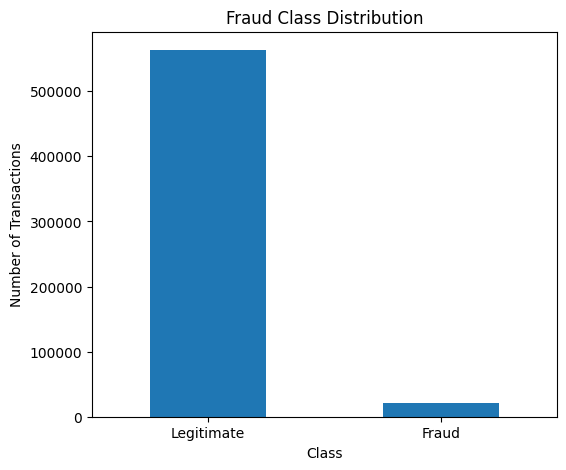

In [105]:


plt.figure(figsize=(6,5))

class_counts.plot(kind="bar")

plt.title("Fraud Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks([0,1],["Legitimate","Fraud"],rotation=0)

plt.show()

Log plot

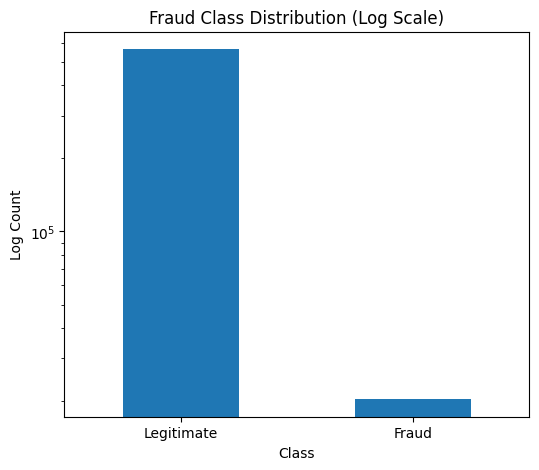

In [106]:
plt.figure(figsize=(6,5))

class_counts.plot(kind="bar")

plt.yscale("log")

plt.title("Fraud Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Log Count")

plt.xticks([0,1],["Legitimate","Fraud"],rotation=0)

plt.show()

Transaction Amount Analysis

In [107]:
print(df_eda["TransactionAmt"].describe())

count    583557.000000
mean        134.668322
std         238.069132
min           0.251000
25%          43.146000
50%          68.500000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


hist plot

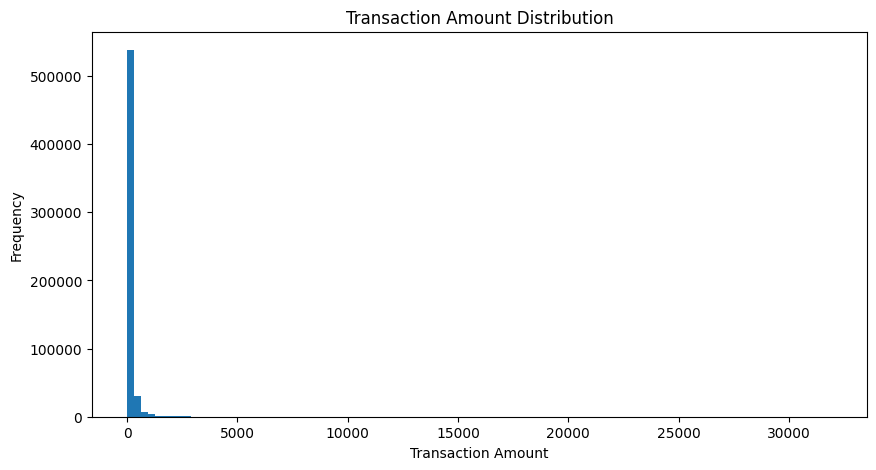

In [108]:


plt.figure(figsize=(10,5))

plt.hist(df_eda["TransactionAmt"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

box plot

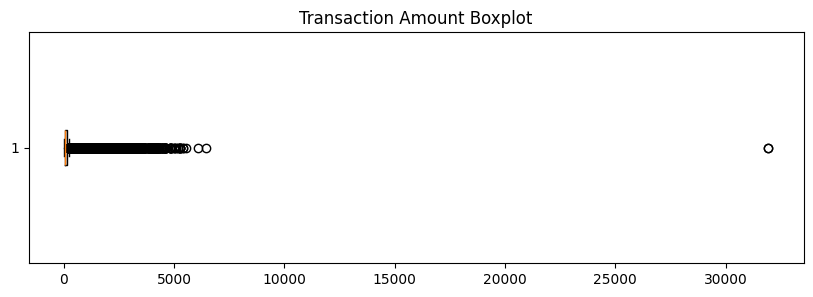

In [109]:
plt.figure(figsize=(10,3))

plt.boxplot(df_eda["TransactionAmt"], vert=False)

plt.title("Transaction Amount Boxplot")

plt.show()

fraud vs legit hist graph

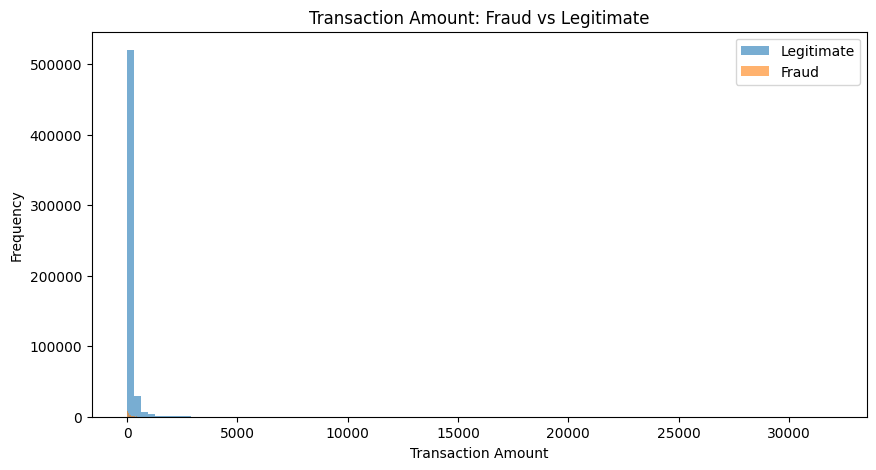

In [110]:
fraud = df_eda[df_eda["isFraud"] == 1]["TransactionAmt"]
legit = df_eda[df_eda["isFraud"] == 0]["TransactionAmt"]

plt.figure(figsize=(10,5))

plt.hist(legit, bins=100, alpha=0.6, label="Legitimate")
plt.hist(fraud, bins=100, alpha=0.6, label="Fraud")

plt.legend()

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

Log distribution(whole data)

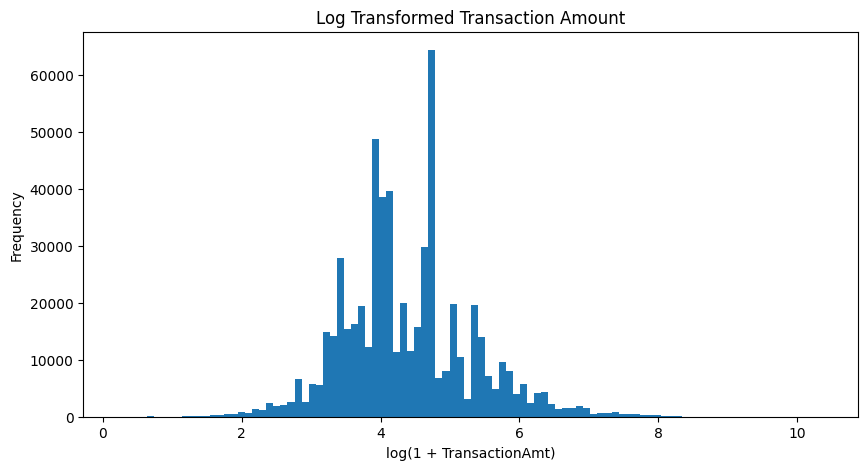

In [111]:


plt.figure(figsize=(10,5))

plt.hist(np.log1p(df_eda["TransactionAmt"]),bins=100)
    
    


plt.title("Log Transformed Transaction Amount")

plt.xlabel("log(1 + TransactionAmt)")
plt.ylabel("Frequency")

plt.show()

Log data(fraud vs legitimate)

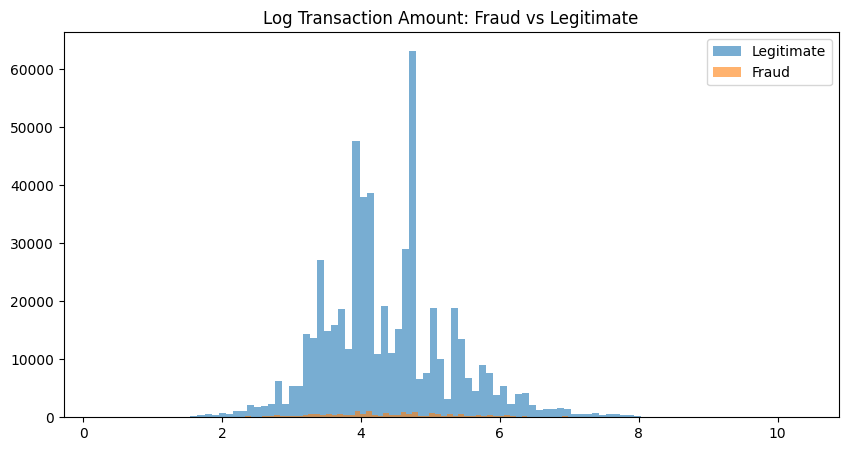

In [112]:
plt.figure(figsize=(10,5))
plt.hist(np.log1p(legit), bins=100, alpha=0.6, label="Legitimate")
plt.hist(np.log1p(fraud), bins=100, alpha=0.6, label="Fraud")
plt.legend()

plt.title("Log Transaction Amount: Fraud vs Legitimate")

plt.show()

In [113]:
print(df_eda["TransactionAmt"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

0.25      43.146
0.50      68.500
0.75     125.000
0.90     274.474
0.95     443.000
0.99    1104.000
Name: TransactionAmt, dtype: float64


Catergorical Fraud analyis

In [114]:
product_counts = df_eda["ProductCD"].value_counts()

print(product_counts)

ProductCD
W    433959
C     67954
R     37354
H     32821
S     11469
Name: count, dtype: int64


In [115]:
product_percent = df_eda["ProductCD"].value_counts(normalize=True).mul(100).round(2)

print(product_percent)

ProductCD
W    74.36
C    11.64
R     6.40
H     5.62
S     1.97
Name: proportion, dtype: float64


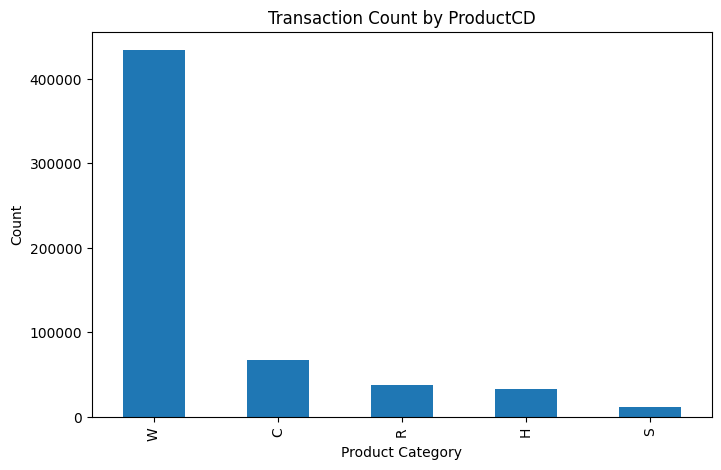

In [116]:


plt.figure(figsize=(8,5))

product_counts.plot(kind="bar")

plt.title("Transaction Count by ProductCD")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

In [117]:
fraud_rate = pd.crosstab(df_eda["ProductCD"], df_eda["isFraud"], normalize="index") * 100

print(fraud_rate.round(2))

isFraud        0      1
ProductCD              
C          88.37  11.63
H          95.25   4.75
R          96.26   3.74
S          94.25   5.75
W          97.96   2.04


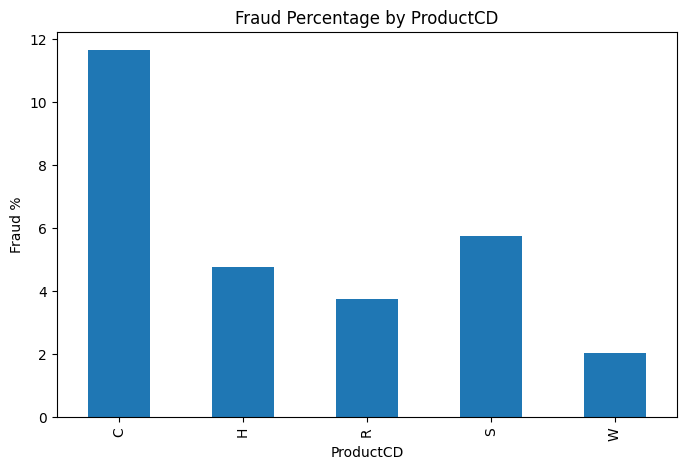

In [118]:
fraud_rate[1].plot(kind="bar",figsize=(8,5))
    
    


plt.title("Fraud Percentage by ProductCD")
plt.ylabel("Fraud %")

plt.show()

Card4 analysis


In [119]:
print("Missing Values:", df_eda["card4"].isnull().sum())
print("Missing Percentage:", round(df_eda["card4"].isnull().mean()*100,2), "%")

Missing Values: 1577
Missing Percentage: 0.27 %


In [120]:
card4_counts = df_eda["card4"].value_counts()
print(card4_counts)

card4
visa                380111
mastercard          187057
american express      8256
discover              6556
Name: count, dtype: int64


In [121]:
card4_percent = (df_eda["card4"].value_counts(normalize=True) * 100).round(2)
print(card4_percent)

card4
visa                65.31
mastercard          32.14
american express     1.42
discover             1.13
Name: proportion, dtype: float64


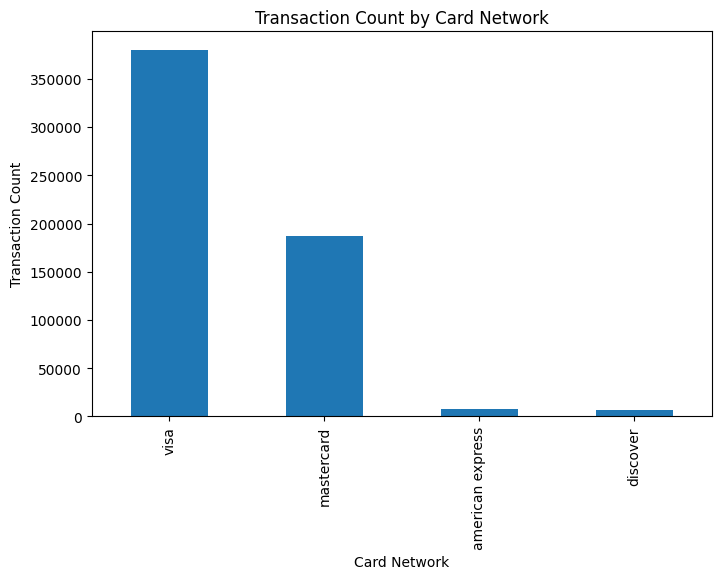

In [122]:
plt.figure(figsize=(8,5))
card4_counts.plot(kind="bar")
plt.title("Transaction Count by Card Network")
plt.xlabel("Card Network")
plt.ylabel("Transaction Count")
plt.show()

In [123]:
card4_fraud = pd.crosstab(df_eda["card4"], df_eda["isFraud"], normalize="index") * 100
print(card4_fraud.round(2))

isFraud               0     1
card4                        
american express  97.14  2.86
discover          92.22  7.78
mastercard        96.58  3.42
visa              96.53  3.47


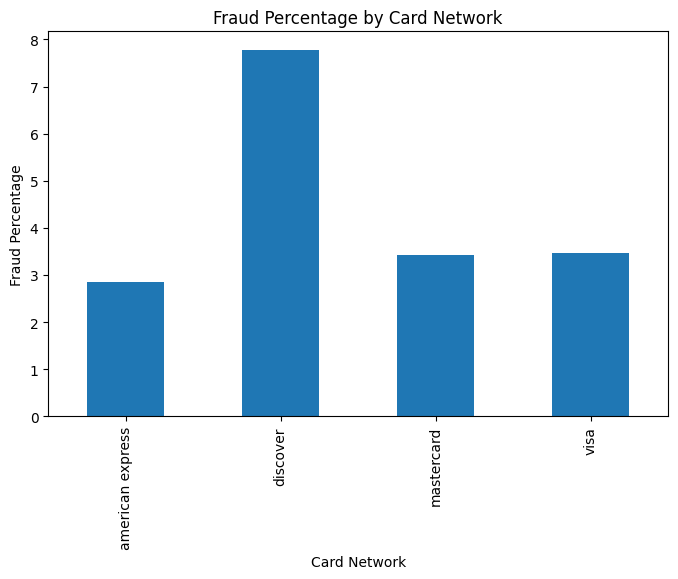

In [124]:
plt.figure(figsize=(8,5))
card4_fraud[1].plot(kind="bar")
plt.title("Fraud Percentage by Card Network")
plt.xlabel("Card Network")
plt.ylabel("Fraud Percentage")
plt.show()

Card6(C6)

In [125]:
print("Missing Values:", df_eda["card6"].isnull().sum())
print("Missing Percentage:", round(df_eda["card6"].isnull().mean()*100,2), "%")

Missing Values: 1571
Missing Percentage: 0.27 %


In [126]:
card6_counts = df_eda["card6"].value_counts()
print(card6_counts)

card6
debit              434686
credit             147255
debit or credit        30
charge card            15
Name: count, dtype: int64


In [127]:
card6_percent = (df_eda["card6"].value_counts(normalize=True) * 100).round(2)
print(card6_percent)

card6
debit              74.69
credit             25.30
debit or credit     0.01
charge card         0.00
Name: proportion, dtype: float64


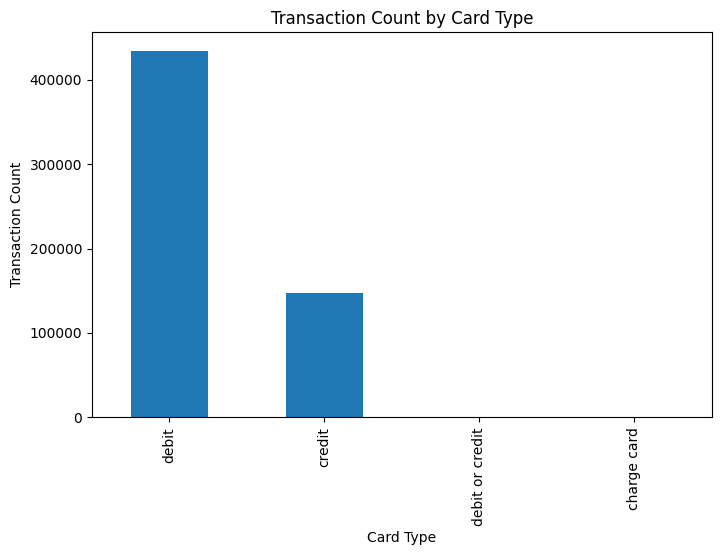

In [128]:
plt.figure(figsize=(8,5))
card6_counts.plot(kind="bar")
plt.title("Transaction Count by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Transaction Count")
plt.show()

In [129]:
card6_fraud = pd.crosstab(df_eda["card6"], df_eda["isFraud"], normalize="index") * 100
print(card6_fraud.round(2))

isFraud               0     1
card6                        
charge card      100.00  0.00
credit            93.34  6.66
debit             97.58  2.42
debit or credit  100.00  0.00


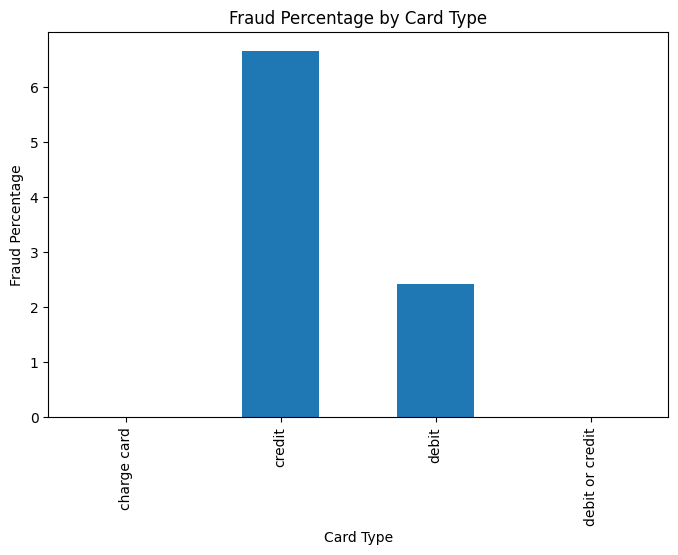

In [130]:
plt.figure(figsize=(8,5))
card6_fraud[1].plot(kind="bar")
plt.title("Fraud Percentage by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Fraud Percentage")
plt.show()

emial eda(p_email)

In [131]:
p_email_counts = df_eda["P_emaildomain"].value_counts()

print(p_email_counts)

P_emaildomain
gmail.com           225705
yahoo.com            99666
hotmail.com          44798
anonymous.com        36491
aol.com              27907
comcast.net           7807
icloud.com            6195
outlook.com           5048
msn.com               4058
att.net               3970
live.com              3007
sbcglobal.net         2933
verizon.net           2671
ymail.com             2373
bellsouth.net         1886
yahoo.com.mx          1531
me.com                1505
cox.net               1374
optonline.net          997
charter.net            792
live.com.mx            738
rocketmail.com         658
mail.com               554
earthlink.net          501
gmail                  488
outlook.es             436
mac.com                433
juno.com               322
aim.com                310
hotmail.es             302
windstream.net         298
roadrunner.com         297
hotmail.fr             290
frontier.com           277
embarqmail.com         255
web.de                 238
netzero.com   

In [132]:
p_email_percent = (df_eda["P_emaildomain"].value_counts(normalize=True) * 100).round(2)

print(p_email_percent)

P_emaildomain
gmail.com           46.05
yahoo.com           20.33
hotmail.com          9.14
anonymous.com        7.44
aol.com              5.69
comcast.net          1.59
icloud.com           1.26
outlook.com          1.03
msn.com              0.83
att.net              0.81
live.com             0.61
sbcglobal.net        0.60
verizon.net          0.54
ymail.com            0.48
bellsouth.net        0.38
yahoo.com.mx         0.31
me.com               0.31
cox.net              0.28
optonline.net        0.20
charter.net          0.16
live.com.mx          0.15
rocketmail.com       0.13
mail.com             0.11
earthlink.net        0.10
gmail                0.10
outlook.es           0.09
mac.com              0.09
juno.com             0.07
aim.com              0.06
hotmail.es           0.06
windstream.net       0.06
roadrunner.com       0.06
hotmail.fr           0.06
frontier.com         0.06
embarqmail.com       0.05
web.de               0.05
netzero.com          0.05
twc.com              0.0

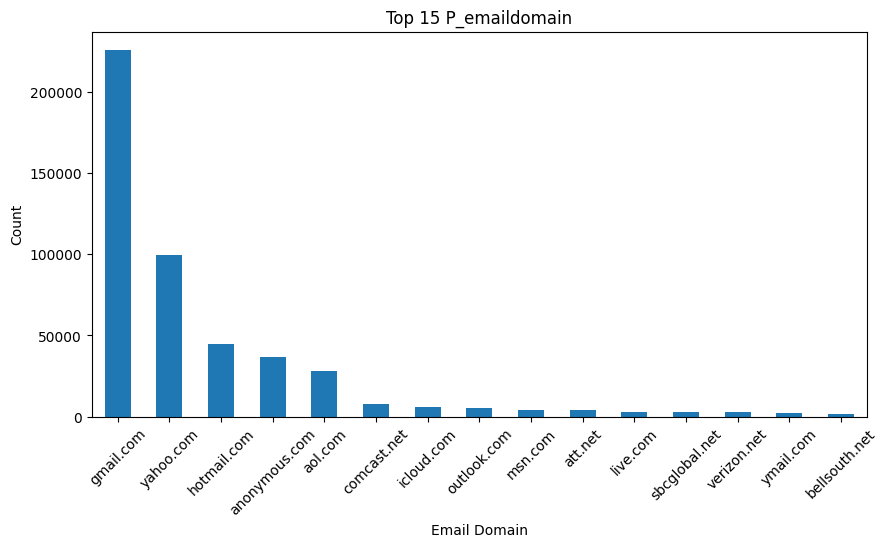

In [133]:
p_email_counts.head(15).plot(kind="bar", figsize=(10,5))

plt.title("Top 15 P_emaildomain")
plt.xlabel("Email Domain")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [134]:
fraud_rate = pd.crosstab(df_eda["P_emaildomain"], df_eda["isFraud"], normalize="index") * 100

print(fraud_rate.round(2).sort_values(by=1, ascending=False))

isFraud                0      1
P_emaildomain                  
protonmail.com     59.21  40.79
mail.com           80.87  19.13
outlook.es         86.93  13.07
aim.com            87.10  12.90
outlook.com        90.57   9.43
hotmail.es         93.38   6.62
hotmail.com        94.73   5.27
live.com.mx        95.39   4.61
gmail.com          95.65   4.35
yahoo.fr           96.18   3.82
mac.com            96.77   3.23
icloud.com         96.84   3.16
comcast.net        96.85   3.15
embarqmail.com     96.86   3.14
bellsouth.net      97.19   2.81
live.com           97.21   2.79
charter.net        97.22   2.78
frontiernet.net    97.35   2.65
suddenlink.net     97.63   2.37
yahoo.com          97.73   2.27
anonymous.com      97.73   2.27
msn.com            97.78   2.22
earthlink.net      97.80   2.20
frontier.com       97.83   2.17
aol.com            97.84   2.16
ymail.com          97.89   2.11
cox.net            97.89   2.11
gmail              97.95   2.05
cableone.net       98.11   1.89
juno.com

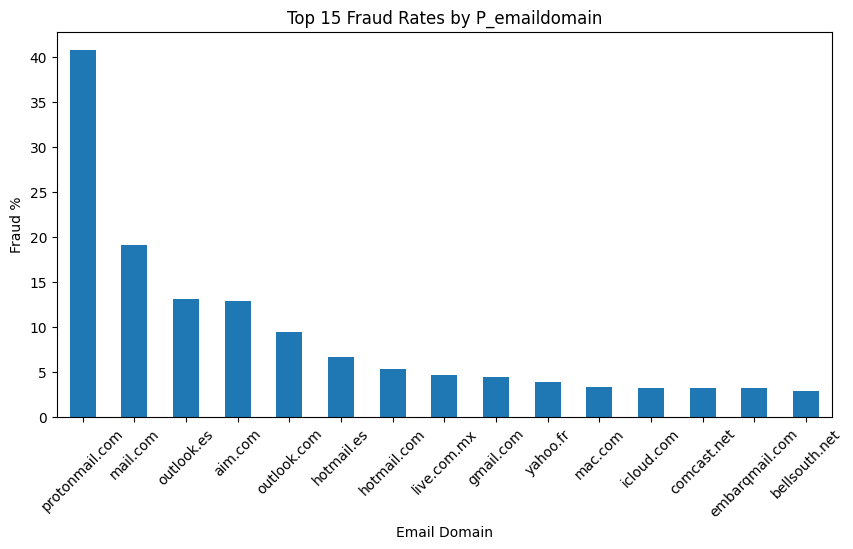

In [135]:
fraud_rate[1].sort_values(ascending=False).head(15).plot(kind="bar", figsize=(10,5))

plt.title("Top 15 Fraud Rates by P_emaildomain")
plt.xlabel("Email Domain")
plt.ylabel("Fraud %")
plt.xticks(rotation=45)
plt.show()

email eda(r_email)

In [136]:
r_email_counts = df_eda["R_emaildomain"].value_counts()

print(r_email_counts)

R_emaildomain
gmail.com           56656
hotmail.com         27274
anonymous.com       20312
yahoo.com           11744
aol.com              3671
outlook.com          2491
comcast.net          1810
yahoo.com.mx         1496
icloud.com           1381
msn.com               849
live.com              757
live.com.mx           741
verizon.net           616
me.com                551
sbcglobal.net         541
cox.net               457
outlook.es            432
att.net               429
bellsouth.net         421
hotmail.es            290
hotmail.fr            288
web.de                235
mac.com               217
prodigy.net.mx        206
ymail.com             204
optonline.net         186
gmx.de                147
charter.net           127
yahoo.fr              125
mail.com              121
hotmail.co.uk         104
gmail                  94
earthlink.net          78
yahoo.de               75
rocketmail.com         69
embarqmail.com         68
scranton.edu           60
yahoo.es               5

In [137]:
r_email_percent = (df_eda["R_emaildomain"].value_counts(normalize=True) * 100).round(2)

print(r_email_percent)

R_emaildomain
gmail.com           41.63
hotmail.com         20.04
anonymous.com       14.93
yahoo.com            8.63
aol.com              2.70
outlook.com          1.83
comcast.net          1.33
yahoo.com.mx         1.10
icloud.com           1.01
msn.com              0.62
live.com             0.56
live.com.mx          0.54
verizon.net          0.45
me.com               0.40
sbcglobal.net        0.40
cox.net              0.34
outlook.es           0.32
att.net              0.32
bellsouth.net        0.31
hotmail.es           0.21
hotmail.fr           0.21
web.de               0.17
mac.com              0.16
prodigy.net.mx       0.15
ymail.com            0.15
optonline.net        0.14
gmx.de               0.11
charter.net          0.09
yahoo.fr             0.09
mail.com             0.09
hotmail.co.uk        0.08
gmail                0.07
earthlink.net        0.06
yahoo.de             0.06
rocketmail.com       0.05
embarqmail.com       0.05
scranton.edu         0.04
yahoo.es             0.0

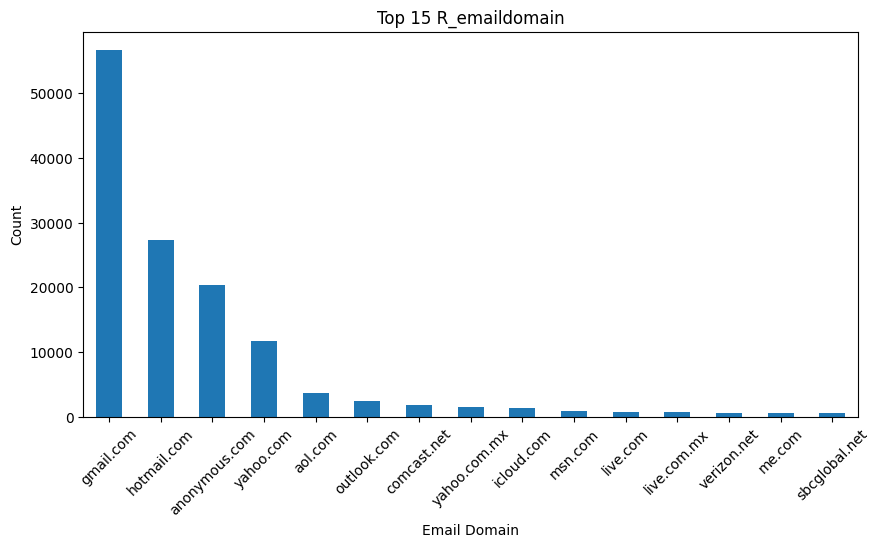

In [138]:
r_email_counts.head(15).plot(kind="bar", figsize=(10,5))

plt.title("Top 15 R_emaildomain")
plt.xlabel("Email Domain")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [139]:
fraud_rate = pd.crosstab(df_eda["R_emaildomain"], df_eda["isFraud"], normalize="index") * 100

print(fraud_rate.round(2).sort_values(by=1, ascending=False))

isFraud                0      1
R_emaildomain                  
protonmail.com      4.88  95.12
mail.com           61.98  38.02
netzero.net        77.78  22.22
outlook.com        83.66  16.34
outlook.es         86.81  13.19
icloud.com         87.26  12.74
gmail.com          88.12  11.88
hotmail.com        92.27   7.73
earthlink.net      92.31   7.69
hotmail.es         93.10   6.90
yahoo.com          94.92   5.08
live.com.mx        95.01   4.99
live.com           95.11   4.89
rocketmail.com     95.65   4.35
suddenlink.net     96.00   4.00
yahoo.fr           96.00   4.00
charter.net        96.06   3.94
ymail.com          96.08   3.92
aol.com            96.49   3.51
yahoo.es           96.49   3.51
aim.com            97.14   2.86
anonymous.com      97.17   2.83
cox.net            97.59   2.41
me.com             98.00   2.00
comcast.net        98.84   1.16
optonline.net      98.92   1.08
yahoo.com.mx       98.93   1.07
mac.com            99.08   0.92
prodigy.net.mx     99.51   0.49
bellsout

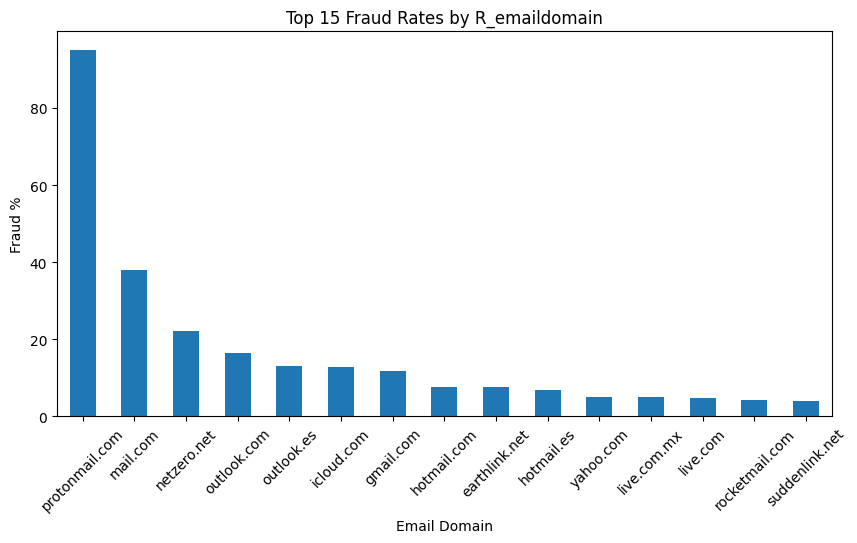

In [140]:
fraud_rate[1].sort_values(ascending=False).head(15).plot(kind="bar", figsize=(10,5))

plt.title("Top 15 Fraud Rates by R_emaildomain")
plt.xlabel("Email Domain")
plt.ylabel("Fraud %")
plt.xticks(rotation=45)
plt.show()

In [141]:
print("Missing Values:", df_eda["R_emaildomain"].isnull().sum())
print("Missing Percentage:", round(df_eda["R_emaildomain"].isnull().mean()*100,2), "%")

Missing Values: 447467
Missing Percentage: 76.68 %


address eda

In [142]:
print("Missing Values:", df_eda["addr1"].isnull().sum())
print("Missing Percentage:", round(df_eda["addr1"].isnull().mean()*100,2), "%")

Missing Values: 65144
Missing Percentage: 11.16 %


In [143]:
addr1_counts = df_eda["addr1"].value_counts()

print(addr1_counts)

addr1
299.0    45771
325.0    42153
204.0    41433
264.0    39399
330.0    25916
         ...  
282.0        1
227.0        1
457.0        1
268.0        1
245.0        1
Name: count, Length: 332, dtype: int64


In [144]:
addr1_percent = (df_eda["addr1"].value_counts(normalize=True) * 100).round(2)

print(addr1_percent)

addr1
299.0    8.83
325.0    8.13
204.0    7.99
264.0    7.60
330.0    5.00
         ... 
282.0    0.00
227.0    0.00
457.0    0.00
268.0    0.00
245.0    0.00
Name: proportion, Length: 332, dtype: float64


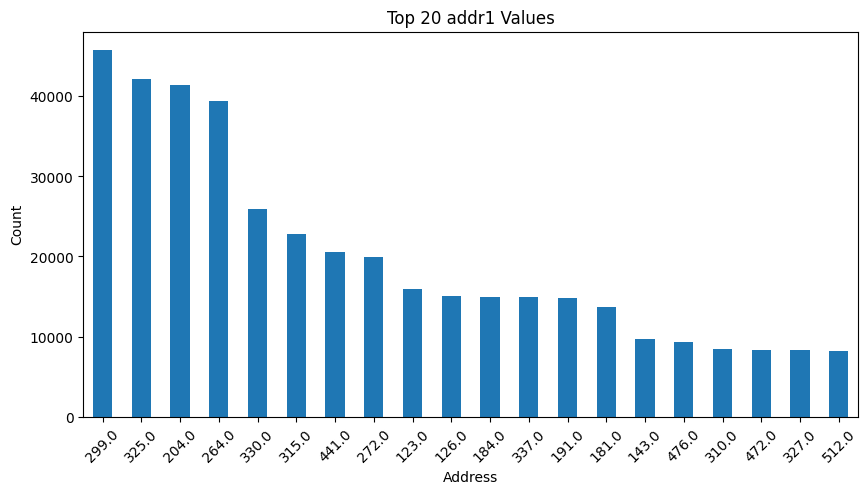

In [145]:
addr1_counts.head(20).plot(kind="bar", figsize=(10,5))

plt.title("Top 20 addr1 Values")
plt.xlabel("Address")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [146]:
fraud_rate = pd.crosstab(df_eda["addr1"], df_eda["isFraud"], normalize="index") * 100

print(fraud_rate.round(2).sort_values(by=1, ascending=False))

isFraud       0      1
addr1                 
305.0     33.33  66.67
483.0     43.48  56.52
501.0     50.00  50.00
471.0     50.00  50.00
466.0     50.00  50.00
...         ...    ...
503.0    100.00   0.00
504.0    100.00   0.00
505.0    100.00   0.00
506.0    100.00   0.00
102.0    100.00   0.00

[332 rows x 2 columns]


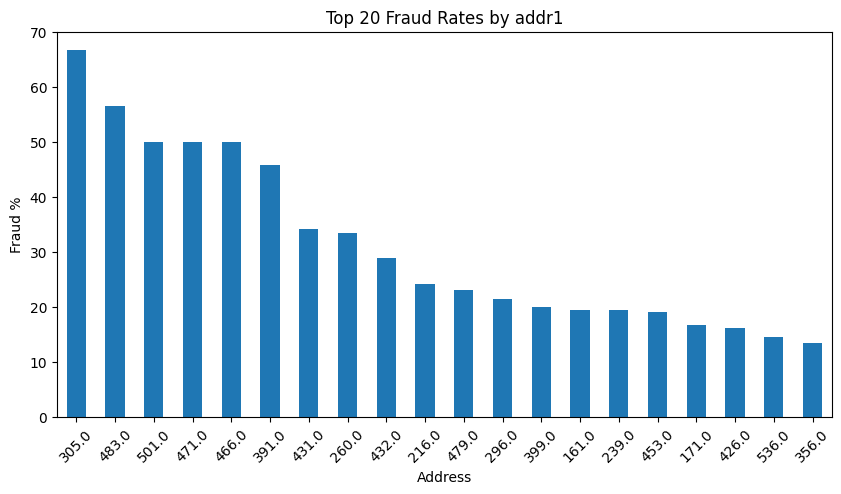

In [147]:
fraud_rate[1].sort_values(ascending=False).head(20).plot(kind="bar", figsize=(10,5))

plt.title("Top 20 Fraud Rates by addr1")
plt.xlabel("Address")
plt.ylabel("Fraud %")
plt.xticks(rotation=45)
plt.show()

addr2-eda

In [148]:
print("Missing Values:", df_eda["addr2"].isnull().sum())
print("Missing Percentage:", round(df_eda["addr2"].isnull().mean()*100,2), "%")

Missing Values: 65144
Missing Percentage: 11.16 %


In [149]:
addr2_counts = df_eda["addr2"].value_counts()
print(addr2_counts)

addr2
87.0    514078
60.0      3081
96.0       630
32.0        91
65.0        81
         ...  
79.0         1
94.0         1
89.0         1
55.0         1
93.0         1
Name: count, Length: 74, dtype: int64


In [150]:
addr2_percent = (df_eda["addr2"].value_counts(normalize=True) * 100).round(2)
print(addr2_percent)

addr2
87.0    99.16
60.0     0.59
96.0     0.12
32.0     0.02
65.0     0.02
        ...  
79.0     0.00
94.0     0.00
89.0     0.00
55.0     0.00
93.0     0.00
Name: proportion, Length: 74, dtype: float64


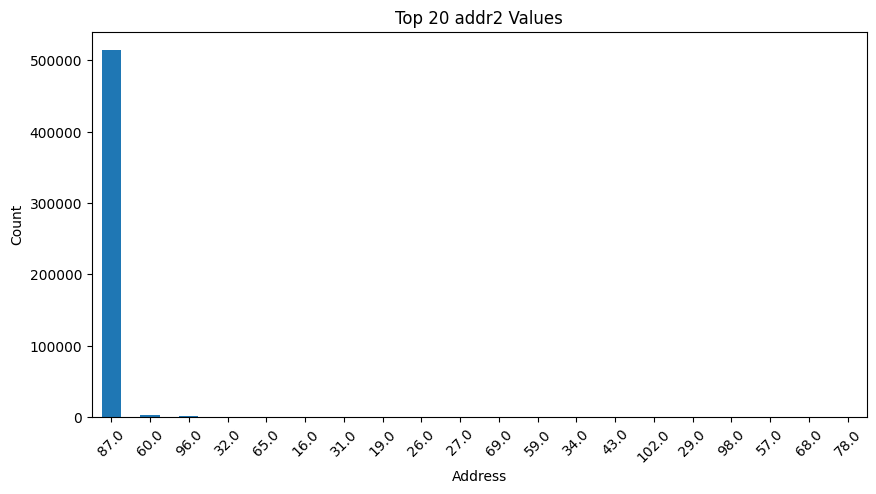

In [151]:
addr2_counts.head(20).plot(kind="bar", figsize=(10,5))

plt.title("Top 20 addr2 Values")
plt.xlabel("Address")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [152]:
fraud_rate = pd.crosstab(df_eda["addr2"], df_eda["isFraud"], normalize="index") * 100
print(fraud_rate.round(2).sort_values(by=1, ascending=False))

isFraud      0      1
addr2                
10.0       0.0  100.0
51.0       0.0  100.0
75.0       0.0  100.0
82.0       0.0  100.0
46.0       0.0  100.0
...        ...    ...
97.0     100.0    0.0
98.0     100.0    0.0
100.0    100.0    0.0
101.0    100.0    0.0
102.0    100.0    0.0

[74 rows x 2 columns]


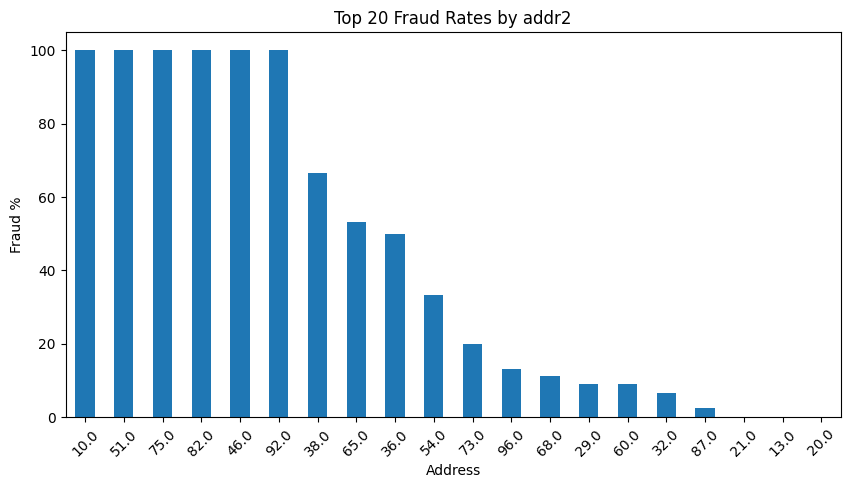

In [153]:
fraud_rate[1].sort_values(ascending=False).head(20).plot(kind="bar", figsize=(10,5))

plt.title("Top 20 Fraud Rates by addr2")
plt.xlabel("Address")
plt.ylabel("Fraud %")
plt.xticks(rotation=45)
plt.show()

M-FEATURE EDA

In [154]:
m_cols = ["M1","M2","M3","M4","M5","M6","M7","M8","M9"]

m_missing = (df_eda[m_cols].isnull().mean() * 100).round(2)

print(m_missing)

M1    46.15
M2    46.15
M3    46.15
M4    47.68
M5    59.40
M6    28.77
M7    58.92
M8    58.92
M9    58.92
dtype: float64


In [155]:
for col in m_cols:
    print(f"\n{col}")
    print(df_eda[col].value_counts(dropna=False))


M1
M1
T      314216
NaN    269316
F          25
Name: count, dtype: int64

M2
M2
T      280984
NaN    269316
F       33257
Name: count, dtype: int64

M3
M3
NaN    269316
T      247783
F       66458
Name: count, dtype: int64

M4
M4
NaN    278217
M0     193861
M2      59343
M1      52136
Name: count, dtype: int64

M5
M5
NaN    346662
F      130819
T      106076
Name: count, dtype: int64

M6
M6
F      224927
T      190755
NaN    167875
Name: count, dtype: int64

M7
M7
NaN    343854
F      207381
T       32322
Name: count, dtype: int64

M8
M8
NaN    343841
F      152260
T       87456
Name: count, dtype: int64

M9
M9
NaN    343841
T      201923
F       37793
Name: count, dtype: int64


In [156]:
for col in m_cols:
    print(f"\n{col}")
    print((df_eda[col].value_counts(normalize=True, dropna=False) * 100).round(2))


M1
M1
T      53.84
NaN    46.15
F       0.00
Name: proportion, dtype: float64

M2
M2
T      48.15
NaN    46.15
F       5.70
Name: proportion, dtype: float64

M3
M3
NaN    46.15
T      42.46
F      11.39
Name: proportion, dtype: float64

M4
M4
NaN    47.68
M0     33.22
M2     10.17
M1      8.93
Name: proportion, dtype: float64

M5
M5
NaN    59.40
F      22.42
T      18.18
Name: proportion, dtype: float64

M6
M6
F      38.54
T      32.69
NaN    28.77
Name: proportion, dtype: float64

M7
M7
NaN    58.92
F      35.54
T       5.54
Name: proportion, dtype: float64

M8
M8
NaN    58.92
F      26.09
T      14.99
Name: proportion, dtype: float64

M9
M9
NaN    58.92
T      34.60
F       6.48
Name: proportion, dtype: float64


In [157]:
for col in m_cols:
    print(f"\n{col}")
    fraud_rate = pd.crosstab(df_eda[col], df_eda["isFraud"], normalize="index") * 100
    print(fraud_rate.round(2))


M1
isFraud       0     1
M1                   
F        100.00  0.00
T         98.02  1.98

M2
isFraud      0     1
M2                  
F        96.54  3.46
T        98.19  1.81

M3
isFraud      0     1
M3                  
F        96.99  3.01
T        98.30  1.70

M4
isFraud      0      1
M4                   
M0       96.34   3.66
M1       97.30   2.70
M2       88.68  11.32

M5
isFraud      0     1
M5                  
F        97.36  2.64
T        96.23  3.77

M6
isFraud      0     1
M6                  
F        97.63  2.37
T        98.30  1.70

M7
isFraud      0     1
M7                  
F        98.07  1.93
T        97.79  2.21

M8
isFraud      0     1
M8                  
F        97.84  2.16
T        98.38  1.62

M9
isFraud      0     1
M9                  
F        97.03  2.97
T        98.22  1.78


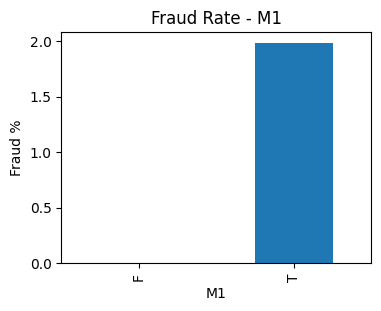

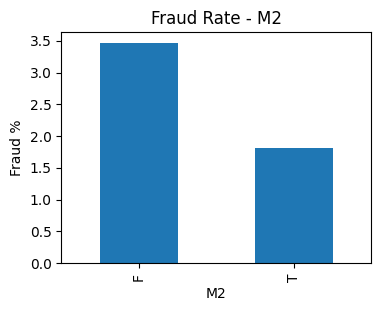

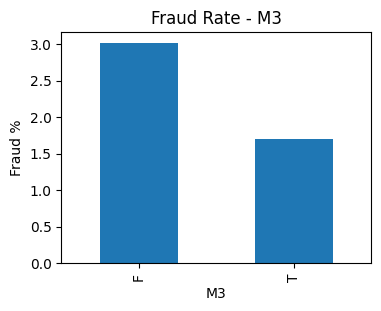

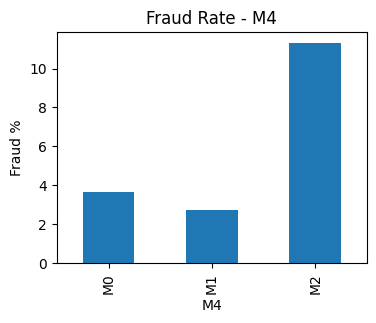

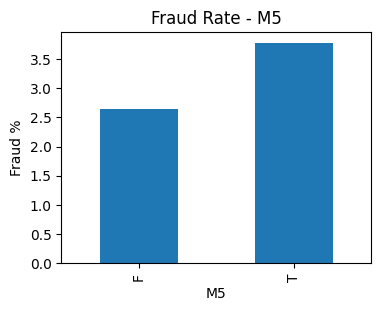

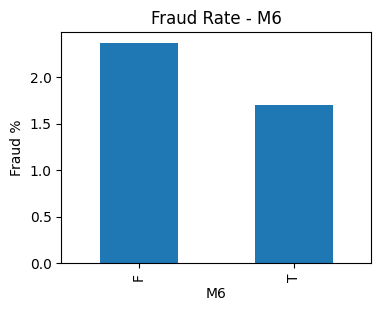

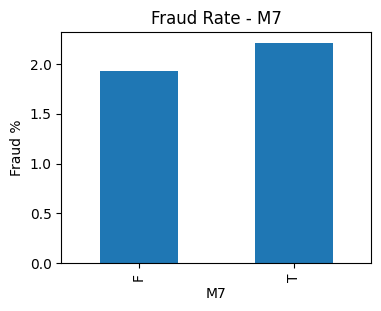

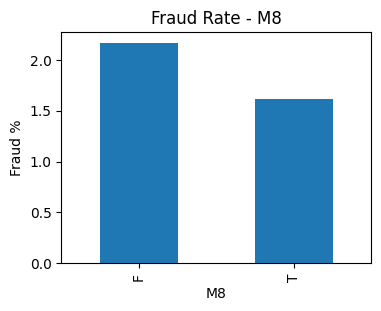

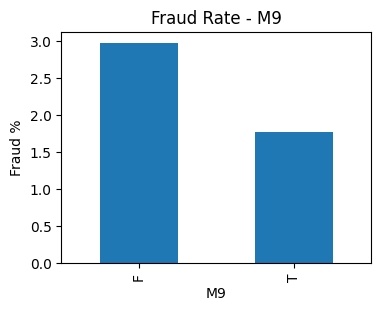

In [158]:
for col in m_cols:
    fraud_rate = pd.crosstab(df_eda[col], df_eda["isFraud"], normalize="index") * 100

    fraud_rate[1].plot(kind="bar", figsize=(4,3))

    plt.title(f"Fraud Rate - {col}")
    plt.ylabel("Fraud %")
    plt.show()

C- EDA

In [159]:
print(df_eda[["C2","C8"]].describe())

                  C2             C8
count  583557.000000  583557.000000
mean       15.345296       5.190156
std       155.447078      95.919781
min         0.000000       0.000000
25%         1.000000       0.000000
50%         1.000000       0.000000
75%         3.000000       0.000000
max      5691.000000    3331.000000


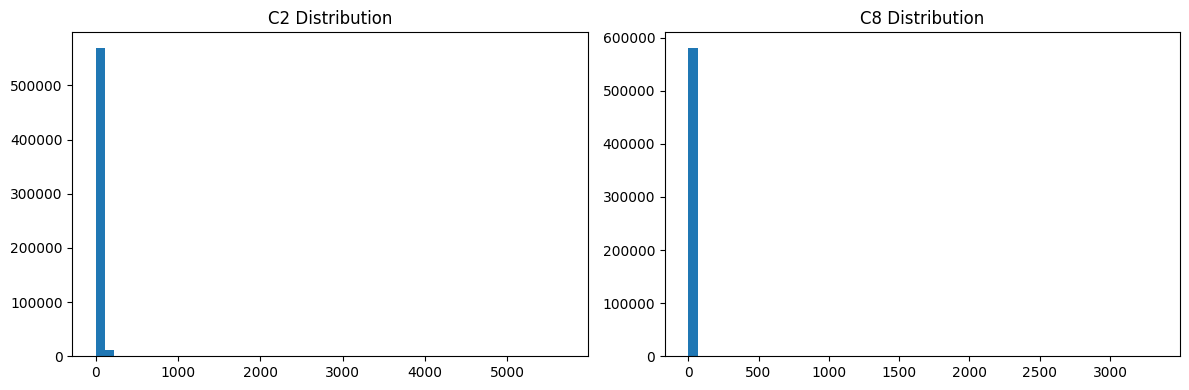

In [160]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_eda["C2"].dropna(), bins=50)
plt.title("C2 Distribution")

plt.subplot(1,2,2)
plt.hist(df_eda["C8"].dropna(), bins=50)
plt.title("C8 Distribution")

plt.tight_layout()
plt.show()

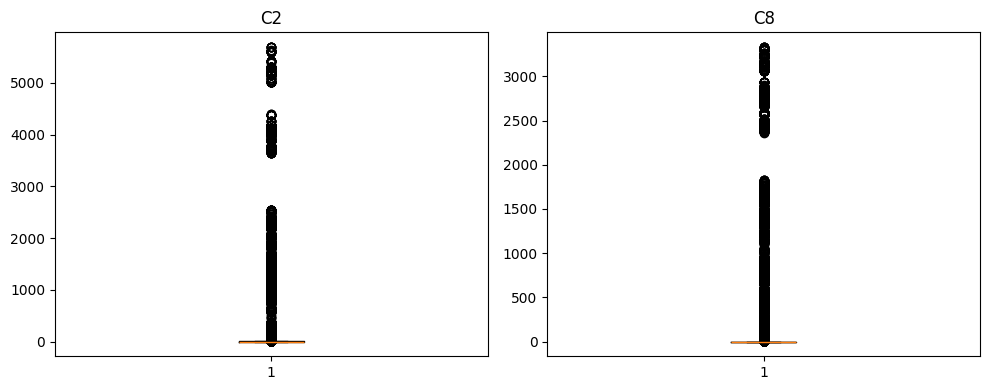

In [161]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df_eda["C2"].dropna())
plt.title("C2")

plt.subplot(1,2,2)
plt.boxplot(df_eda["C8"].dropna())
plt.title("C8")

plt.tight_layout()
plt.show()

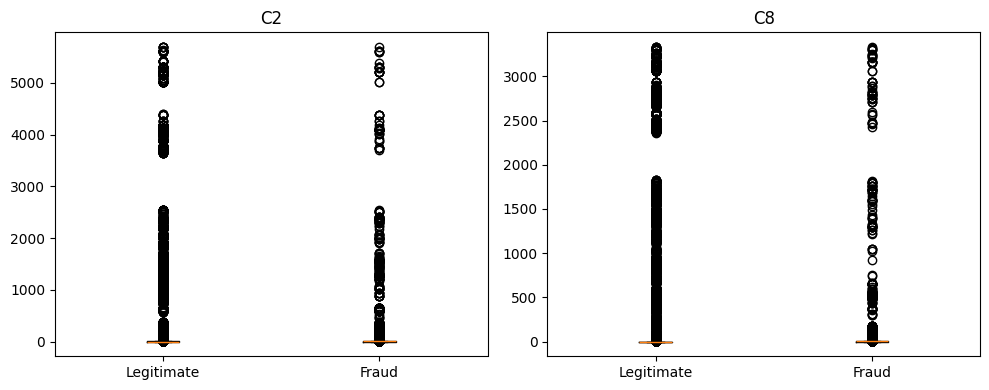

In [162]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot([
    df_eda[df_eda["isFraud"]==0]["C2"].dropna(),
    df_eda[df_eda["isFraud"]==1]["C2"].dropna()
])

plt.xticks([1,2],["Legitimate","Fraud"])
plt.title("C2")

plt.subplot(1,2,2)
plt.boxplot([
    df_eda[df_eda["isFraud"]==0]["C8"].dropna(),
    df_eda[df_eda["isFraud"]==1]["C8"].dropna()
])

plt.xticks([1,2],["Legitimate","Fraud"])
plt.title("C8")

plt.tight_layout()
plt.show()

D-EDA

In [163]:
d_cols = ["D1","D2","D4","D7","D8","D10","D15"]

In [164]:
print((df_eda[d_cols].isnull().mean()*100).round(2))

D1      0.21
D2     47.62
D4     28.68
D7     93.40
D8     87.29
D10    12.92
D15    15.17
dtype: float64


In [165]:
print(df_eda[d_cols].describe())

                 D1             D2             D4            D7            D8  \
count  582329.00000  305678.000000  416173.000000  38535.000000  74198.000000   
mean       94.12706     169.373570     139.688204     41.678085    145.934635   
std       157.39567     177.079479     190.697362     99.773796    231.643300   
min         0.00000       0.000000    -122.000000      0.000000      0.000000   
25%         0.00000      25.000000       0.000000      0.000000      0.958333   
50%         3.00000      97.000000      26.000000      0.000000     37.791664   
75%       121.00000     276.000000     253.000000     17.000000    187.666672   
max       640.00000     640.000000     864.000000    843.000000   1707.791626   

                 D10            D15  
count  508150.000000  495052.000000  
mean      123.645886     163.358084  
std       182.221043     202.313266  
min         0.000000     -83.000000  
25%         0.000000       0.000000  
50%        15.000000      52.000000  
75% 

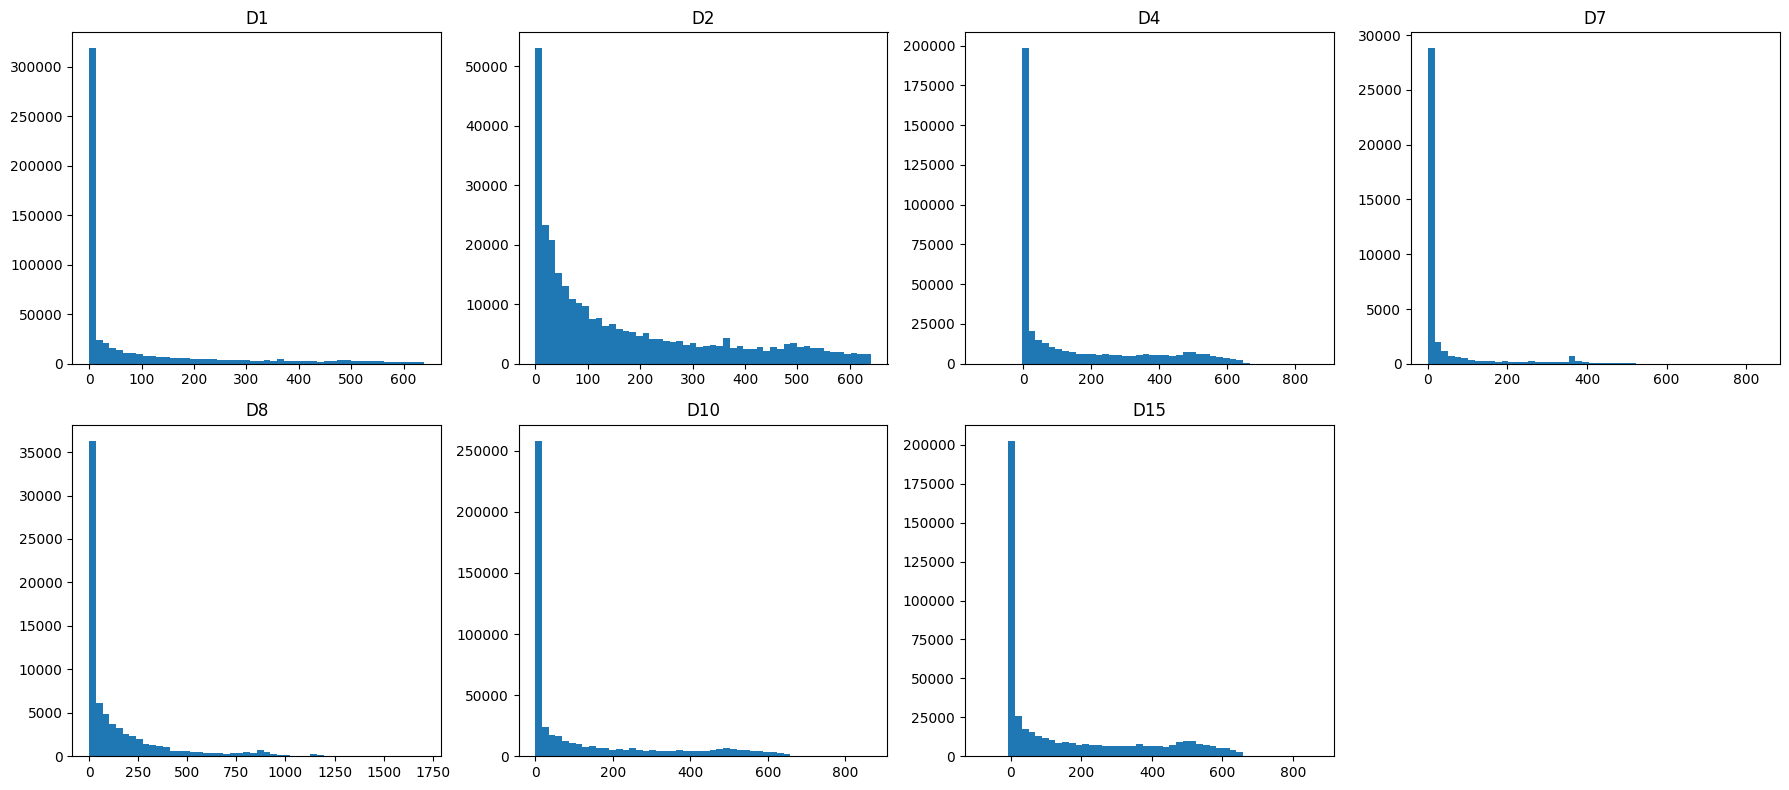

In [166]:
plt.figure(figsize=(18,8))

for i,col in enumerate(d_cols,1):
    plt.subplot(2,4,i)
    plt.hist(df_eda[col].dropna(), bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

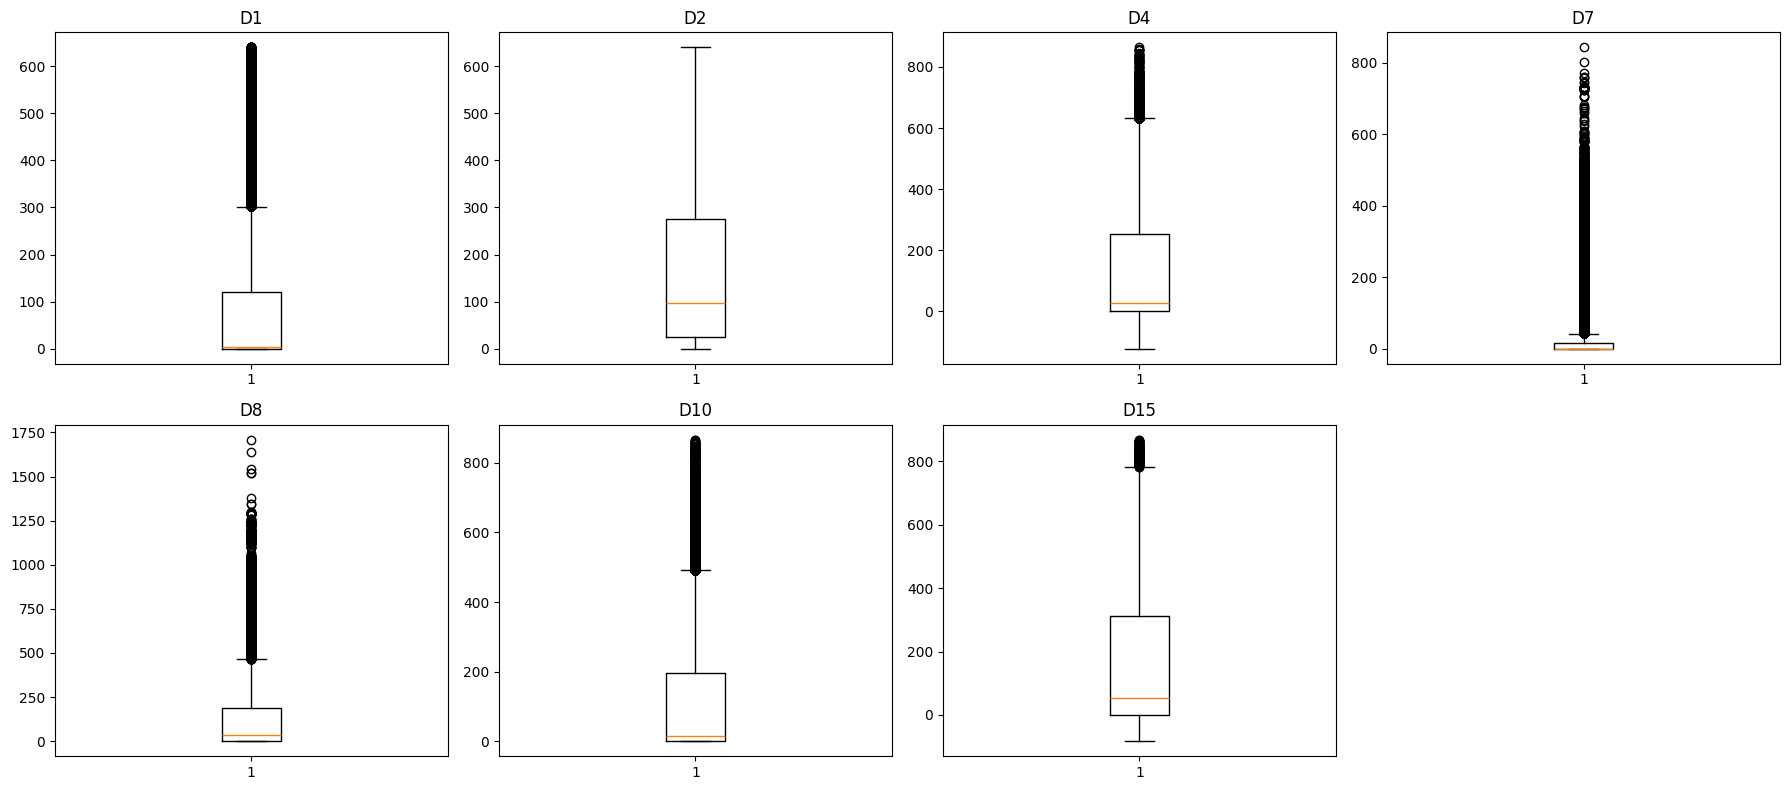

In [167]:
plt.figure(figsize=(18,8))

for i,col in enumerate(d_cols,1):
    plt.subplot(2,4,i)
    plt.boxplot(df_eda[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

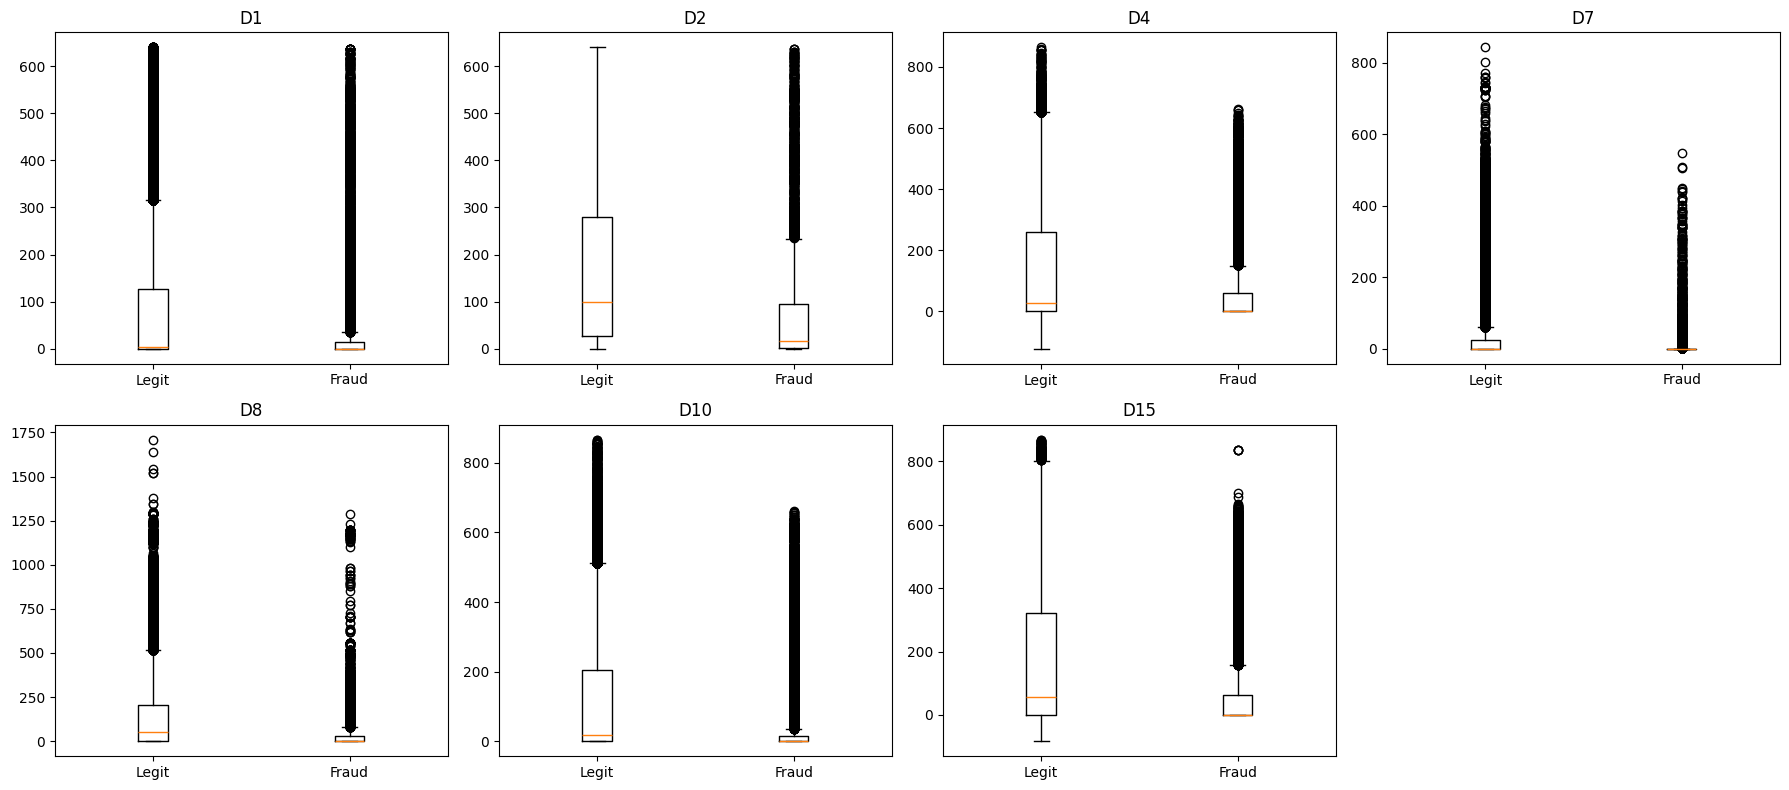

In [168]:
plt.figure(figsize=(18,8))

for i,col in enumerate(d_cols,1):
    plt.subplot(2,4,i)

    plt.boxplot([
        df_eda[df_eda["isFraud"]==0][col].dropna(),
        df_eda[df_eda["isFraud"]==1][col].dropna()
    ])

    plt.xticks([1,2],["Legit","Fraud"])
    plt.title(col)

plt.tight_layout()
plt.show()

TransactionDT- EDA

In [169]:
!pip uninstall pyarrow -y
!pip install pyarrow==14.0.1

Found existing installation: pyarrow 14.0.1
Uninstalling pyarrow-14.0.1:
  Successfully uninstalled pyarrow-14.0.1
  Using cached pyarrow-14.0.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
Using cached pyarrow-14.0.1-cp312-cp312-win_amd64.whl (25.0 MB)


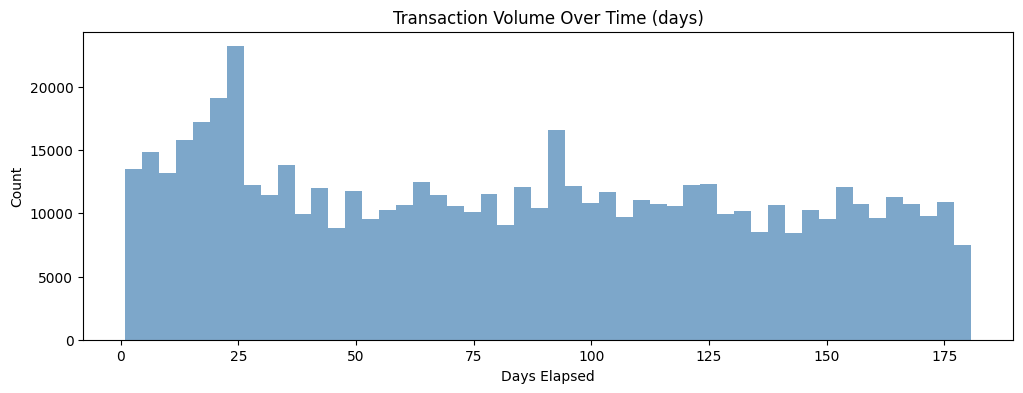

C:\Users\soham\AppData\Local\Temp\ipykernel_10016\3992111359.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_over_time = df_eda.groupby('day_bin')['isFraud'].mean() * 100


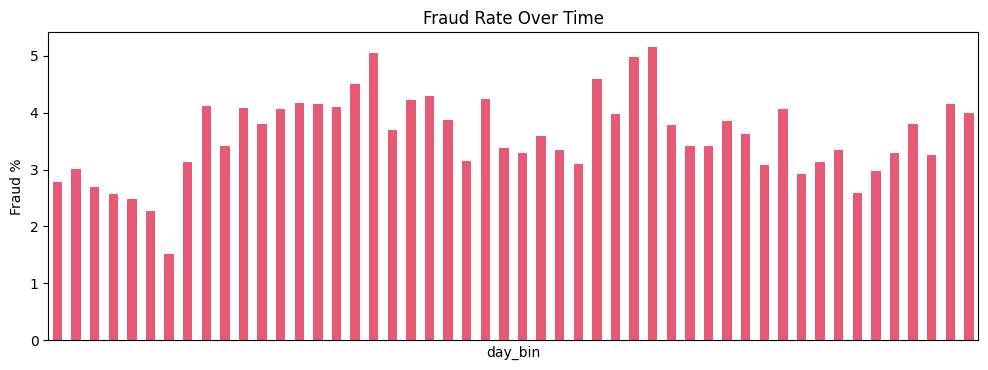

Window 1: 233,422 rows | fraud: 3.17%
Window 2: 175,067 rows | fraud: 3.97%
Window 3: 175,068 rows | fraud: 3.44%
Windows saved as CSV.


In [170]:
import os

# convert to days for readability
df_eda['day'] = df_eda['TransactionDT'] / 86400

# plot transaction volume over time
plt.figure(figsize=(12,4))
plt.hist(df_eda['day'], bins=50, color='steelblue', alpha=0.7)
plt.title('Transaction Volume Over Time (days)')
plt.xlabel('Days Elapsed')
plt.ylabel('Count')
plt.show()

# plot fraud rate over time
df_eda['day_bin'] = pd.cut(df_eda['day'], bins=50)
fraud_over_time = df_eda.groupby('day_bin')['isFraud'].mean() * 100
plt.figure(figsize=(12,4))
fraud_over_time.plot(kind='bar', color='crimson', alpha=0.7)
plt.title('Fraud Rate Over Time')
plt.ylabel('Fraud %')
plt.xticks([])
plt.show()

# window split
df_sorted = df_eda.sort_values('TransactionDT').reset_index(drop=True)
total = len(df_sorted)
w1 = df_sorted.iloc[:int(total*0.4)]
w2 = df_sorted.iloc[int(total*0.4):int(total*0.7)]
w3 = df_sorted.iloc[int(total*0.7):]

print(f"Window 1: {len(w1):,} rows | fraud: {w1['isFraud'].mean()*100:.2f}%")
print(f"Window 2: {len(w2):,} rows | fraud: {w2['isFraud'].mean()*100:.2f}%")
print(f"Window 3: {len(w3):,} rows | fraud: {w3['isFraud'].mean()*100:.2f}%")

# drop helper cols before saving
df_sorted = df_sorted.drop(columns=['day', 'day_bin'])
w1 = w1.drop(columns=['day', 'day_bin'])
w2 = w2.drop(columns=['day', 'day_bin'])
w3 = w3.drop(columns=['day', 'day_bin'])

os.makedirs('data/windows', exist_ok=True)
w1.to_csv('data/windows/window_1.csv', index=False)
w2.to_csv('data/windows/window_2.csv', index=False)
w3.to_csv('data/windows/window_3.csv', index=False)
print("Windows saved as CSV.")

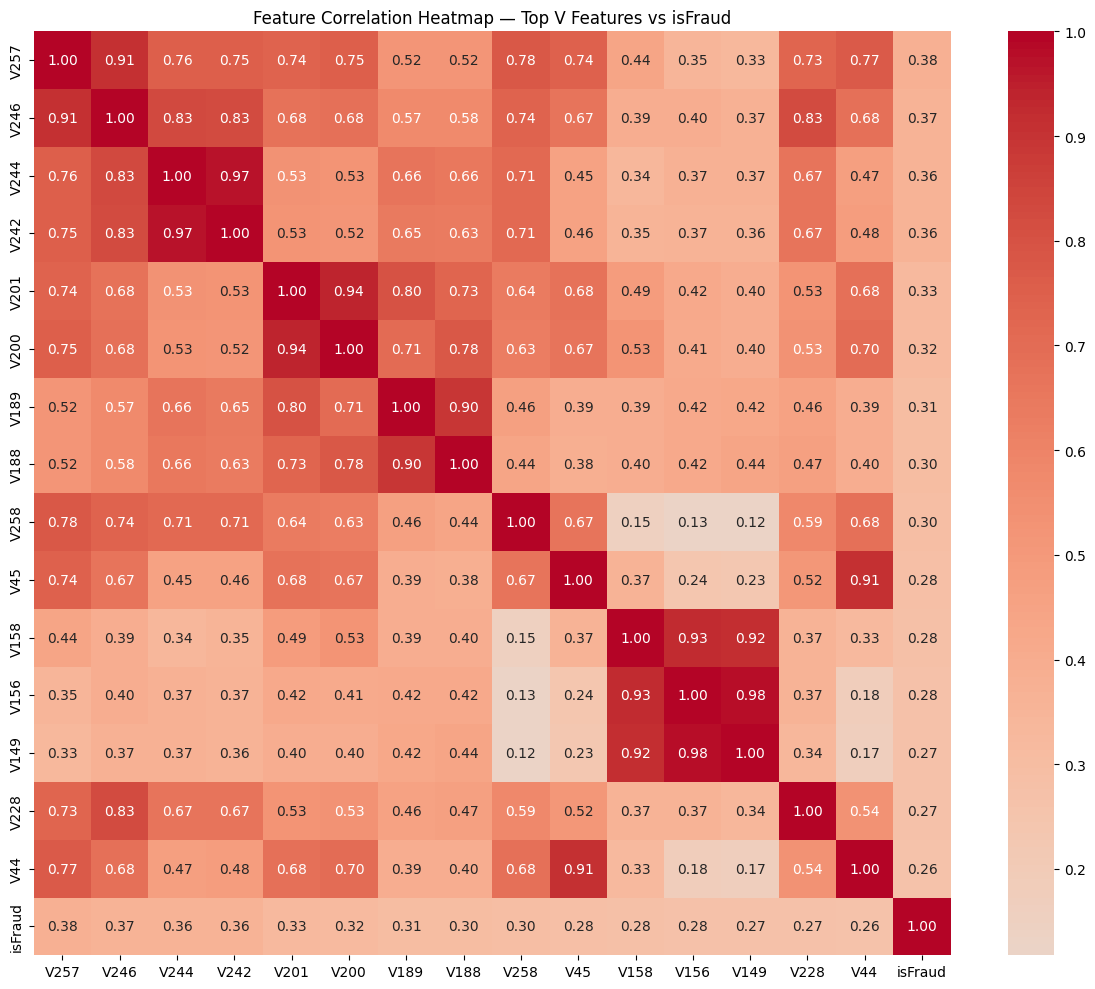

In [171]:
heatmap_cols = [c for c in v_cols_selected if c in df_eda.columns]
plt.figure(figsize=(12,10))
sns.heatmap(df_eda[heatmap_cols + ['isFraud']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap — Top V Features vs isFraud')
plt.tight_layout()
plt.show()

In [172]:
print("=== EDA SUMMARY ===")
print(f"Total rows: {len(df_eda):,}")
print(f"Features selected: {len(final_cols)}")
print(f"Fraud rate: {df_eda['isFraud'].mean()*100:.2f}%")
print(f"Window 1: {len(w1):,} rows | fraud: {w1['isFraud'].mean()*100:.2f}%")
print(f"Window 2: {len(w2):,} rows | fraud: {w2['isFraud'].mean()*100:.2f}%")
print(f"Window 3: {len(w3):,} rows | fraud: {w3['isFraud'].mean()*100:.2f}%")
print(f"High null cols with fraud signal: D7, D8, V257, R_emaildomain")
print(f"Missingness indicator needed for: D7, D8, V257, V246, R_emaildomain, V201")

=== EDA SUMMARY ===
Total rows: 583,557
Features selected: 48
Fraud rate: 3.49%
Window 1: 233,422 rows | fraud: 3.17%
Window 2: 175,067 rows | fraud: 3.97%
Window 3: 175,068 rows | fraud: 3.44%
High null cols with fraud signal: D7, D8, V257, R_emaildomain
Missingness indicator needed for: D7, D8, V257, V246, R_emaildomain, V201
